In [19]:
import geopandas as gpd
import ee
import json
import geemap

In [ ]:
# authentication

ee.Authenticate()
ee.Initialize(project='deep-learning-detroit')


Successfully saved authorization token.


In [ ]:
# detroit geometry

gdf = gpd.read_file("data/City_of_Detroit_Boundary.geojson")

# Keep only geometry column
gdf_geom = gdf[['geometry']]

geojson_dict = json.loads(gdf_geom.to_json())
detroit_ee = ee.Geometry(geojson_dict['features'][0]['geometry'])

In [16]:
# embeddings fetch
dataset = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

emb_2017 = dataset.filterDate("2017-01-01", "2018-01-01").filterBounds(detroit_ee).mosaic()
emb_2023 = dataset.filterDate("2023-01-01", "2024-01-01").filterBounds(detroit_ee).mosaic()

In [17]:
diff = emb_2023.subtract(emb_2017)
change_magnitude = diff.pow(2).reduce(ee.Reducer.sum()).sqrt().clip(detroit_ee)

In [20]:
sample = change_magnitude.rename('change').sample(
    region=detroit_ee,
    scale=30,
    numPixels=5000,
    seed=42,
    geometries=True
)

df = geemap.ee_to_df(sample)
print(df.head())
print(df.shape)

     change
0  0.237431
1  0.269681
2  0.262951
3  0.204550
4  0.213368
(5000, 1)


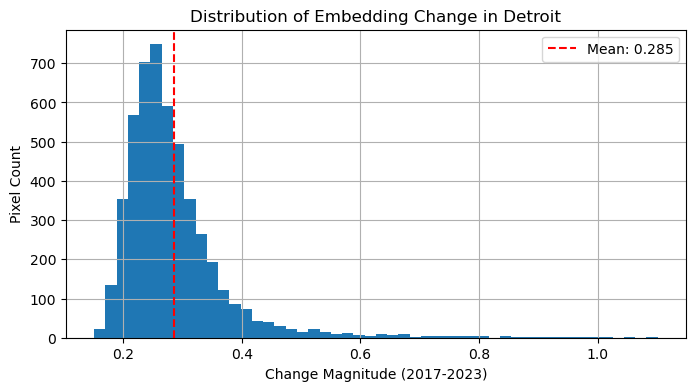

Mean change: 0.2849
Max change:  1.1010
Top 10% threshold: 0.3684


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# First get the change map as an actual image export
change_viz = change_magnitude.visualize(
    min=0, max=0.5, 
    palette=['blue', 'white', 'red']
)

# Quick histogram of change values
df['change'].hist(bins=50, figsize=(8,4))
plt.xlabel('Change Magnitude (2017-2023)')
plt.ylabel('Pixel Count')
plt.title('Distribution of Embedding Change in Detroit')
plt.axvline(df['change'].mean(), color='red', linestyle='--', label=f'Mean: {df["change"].mean():.3f}')
plt.legend()
plt.show()

print(f"Mean change: {df['change'].mean():.4f}")
print(f"Max change:  {df['change'].max():.4f}")
print(f"Top 10% threshold: {df['change'].quantile(0.9):.4f}")

In [22]:
m = geemap.Map()
m.centerObject(detroit_ee, zoom=11)

# Add basemap for context
m.add_basemap("SATELLITE")

# Add the change layer
change_vis = {
    'min': 0,
    'max': 0.5,
    'palette': ['#2166ac', '#f7f7f7', '#d6604d', '#b2182b']
}
m.addLayer(change_magnitude, change_vis, 'Embedding Change 2017-2023')

# Add detroit boundary
detroit_fc = ee.FeatureCollection([ee.Feature(detroit_ee)])
m.addLayer(detroit_fc, {}, 'Detroit Boundary')

m.add_colorbar(change_vis, label='Change Magnitude')
m

Map(center=[42.383446351197, -83.10224445245052], controls=(WidgetControl(options=['position', 'transparent_bg…